In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Vientiane_final.csv to Vientiane_final.csv


In [15]:
df = pd.read_csv("Vientiane_final.csv")
df.head()

,YEAR,MONTH,ALLSKY_SFC_SW_DWN,T2M,T2MDEW,T2MWET,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,QV2M,WS2M,GWETTOP
0,1995,1,19.53,21.36,17.68,19.52,27.32,15.69,0.01,80.76,12.80,1.85,0.62
1,1995,1,17.67,20.32,16.36,18.34,25.94,16.46,0.04,79.18,11.79,2.12,0.62
2,1995,1,19.10,20.69,17.08,18.88,26.43,16.69,0.00,81.10,12.36,1.52,0.62
3,1995,1,19.64,17.64,12.95,15.30,23.11,13.31,0.00,75.19,9.47,2.47,0.62
4,1995,1,18.96,15.32,8.12,11.72,21.84,9.98,0.00,64.23,6.83,2.44,0.61


In [16]:
features = ["YEAR","MONTH","ALLSKY_SFC_SW_DWN","T2M","T2MDEW","T2MWET","T2M_MAX","T2M_MIN","RH2M","QV2M","WS2M","GWETTOP"]
target = "PRECTOTCORR"

In [17]:
train = df[df["YEAR"] <= 2020]
test  = df[(df["YEAR"] >= 2021) & (df["YEAR"] <= 2025)]

X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]

In [18]:
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

GradientBoostingRegressor(n_estimators=200, random_state=42)

In [20]:
preds = np.clip(model.predict(X_test), 0, None) # Predictions

In [21]:
# ── Evaluation Metrics ───────────────────────────────────────
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2   = r2_score(y_test, preds)

print(f"RMSE     : {rmse:.3f} mm/day")
print(f"R2 Score : {r2:.4f}")

RMSE     : 4.409 mm/day
R2 Score : 0.5572


In [22]:
results = test[["YEAR", "MONTH"]].copy()
results["Actual"] = y_test.values
results["Predicted"] = preds
monthly_results = results.groupby(
    ["YEAR", "MONTH"]
).mean().reset_index()  #Results Table

In [25]:
selected_year = 2025

year_data = monthly_results[
    monthly_results["YEAR"] == selected_year
]

print(f"\nMonthly Rainfall Comparison for {selected_year}")
display(year_data)


Monthly Rainfall Comparison for 2025


,YEAR,MONTH,Actual,Predicted
48,2025,1,0.000000,0.011501
49,2025,2,1.100000,0.347825
50,2025,3,0.386452,0.501012
51,2025,4,2.254667,1.146613
52,2025,5,6.997419,6.098971
53,2025,6,5.976000,6.437730
54,2025,7,7.642903,8.939030
55,2025,8,7.187742,7.623932
56,2025,9,10.292667,9.919992
57,2025,10,2.627742,4.261479


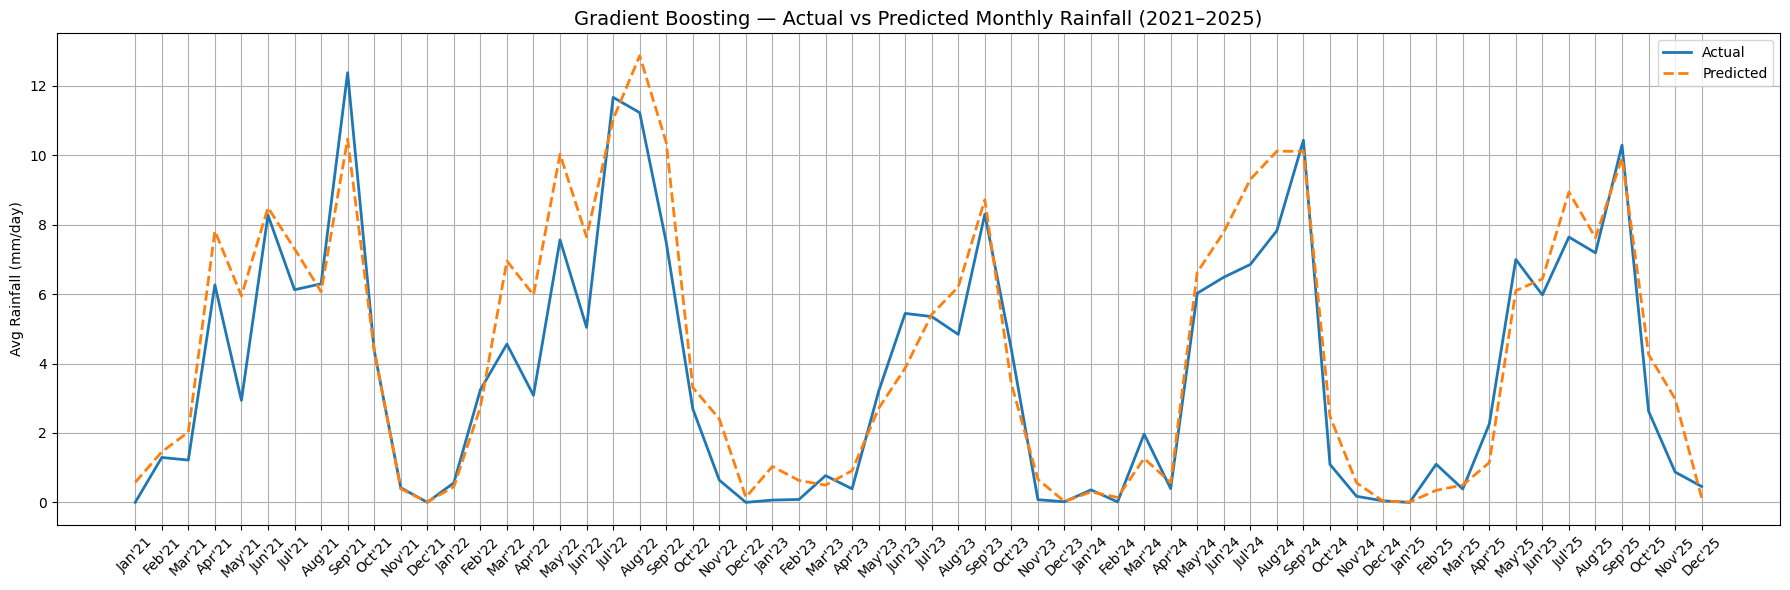

In [26]:
# Graph
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

timeline_labels = [
    f"{month_names[int(row.MONTH)-1]}'{str(int(row.YEAR))[-2:]}"
    for _, row in monthly_results.iterrows()
]

plt.figure(figsize=(18,6))

plt.plot(
    timeline_labels,
    monthly_results["Actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    timeline_labels,
    monthly_results["Predicted"],
    linestyle="--",
    label="Predicted",
    linewidth=2
)

plt.title(
    "Gradient Boosting — Actual vs Predicted Monthly Rainfall (2021–2025)",
    fontsize=14
)
plt.ylabel("Avg Rainfall (mm/day)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


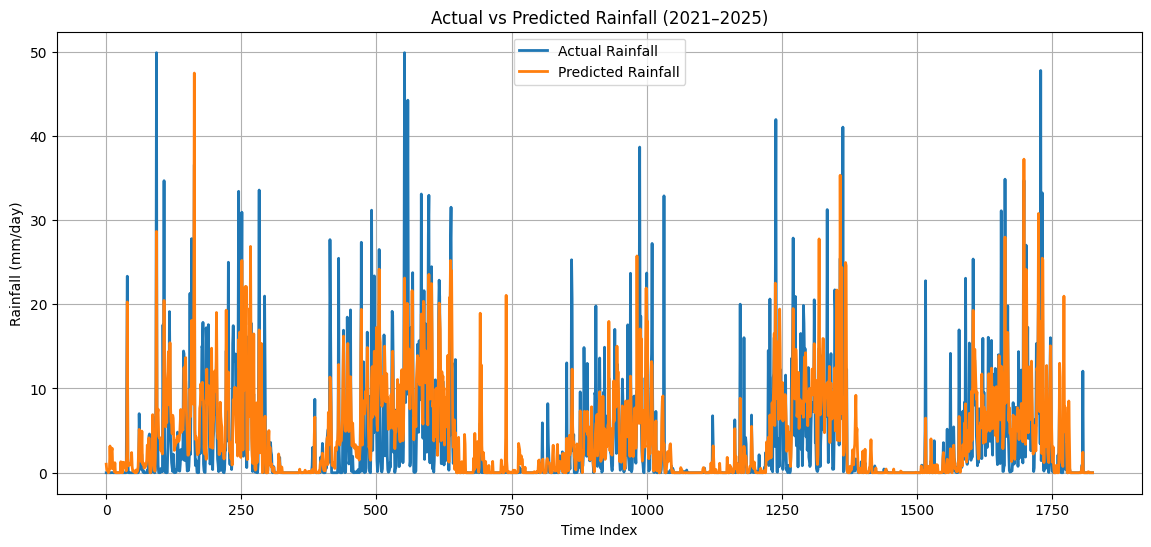

In [27]:
# ── Graph: Actual vs Predicted
plt.figure(figsize=(14,6))

plt.plot(results["Actual"].values, label="Actual Rainfall", linewidth=2)
plt.plot(results["Predicted"].values, label="Predicted Rainfall", linewidth=2)

plt.title("Actual vs Predicted Rainfall (2021–2025)")
plt.xlabel("Time Index")
plt.ylabel("Rainfall (mm/day)")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
# Feature Importance
fi = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nTop Feature Importances:")
display(fi)


Top Feature Importances:


,0
QV2M,0.232277
RH2M,0.200253
ALLSKY_SFC_SW_DWN,0.157640
T2MDEW,0.129656
GWETTOP,0.116070
MONTH,0.068682
YEAR,0.028770
WS2M,0.023212
T2M_MIN,0.022241
T2MWET,0.009789
